In [1]:
!pip install opencv-python

'pip' is not recognized as an internal or external command,
operable program or batch file.


## 1.Import Required Libraries

In [22]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

## 2.Check Dataset Structure

In [24]:
dataset_path = "Intel Image Dataset"

print("Folders in dataset:")
print(os.listdir(dataset_path))

Folders in dataset:
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## 3.Select an Image

In [28]:
folder = os.path.join(dataset_path, "buildings")

image_name = os.listdir(folder)[0]

image_path = os.path.join(folder, image_name)

print("Image selected:", image_name)

Image selected: 20057.jpg


## 4.Load and Display the Original Image

Image Shape: (150, 150, 3)


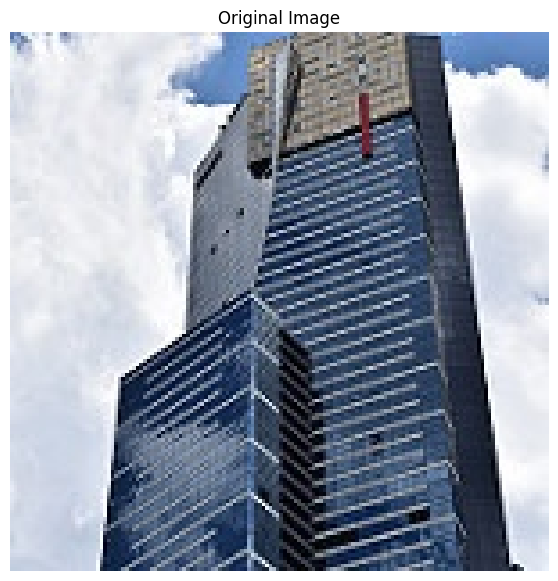

In [30]:
image = cv2.imread(image_path)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("Image Shape:", image.shape)

plt.figure(figsize=(7,7))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

## 5.Resize the Image

(256, 256, 3)


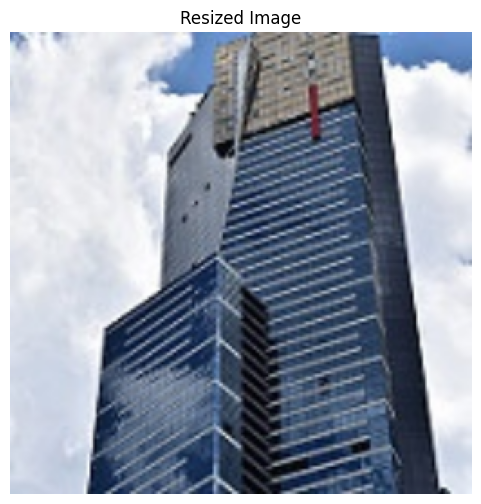

In [31]:
image = cv2.resize(image, (256,256))

print(image.shape)

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title("Resized Image")
plt.axis("off")
plt.show()

## 6. Flatten the Image into Pixel Data

In [32]:
pixel_values = image.reshape((-1,3))

pixel_values = np.float32(pixel_values)

print("Pixel Matrix Shape:", pixel_values.shape)

Pixel Matrix Shape: (65536, 3)


## 7. Apply K-Means Clustering

In [33]:
k = 5

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(pixel_values)

print("K-Means Completed!")

K-Means Completed!


## 8.Display Cluster Centers

In [34]:
centers = np.uint8(kmeans.cluster_centers_)

print("Cluster Centers:\n")
print(centers)

Cluster Centers:

[[225 229 237]
 [ 92 106 127]
 [ 53  67  91]
 [127 141 162]
 [ 25  34  53]]


## 9.Generate the Segmented Image

In [35]:
segmented_data = centers[labels]

segmented_image = segmented_data.reshape(image.shape)

## 10.Visualize the Segmentation Result

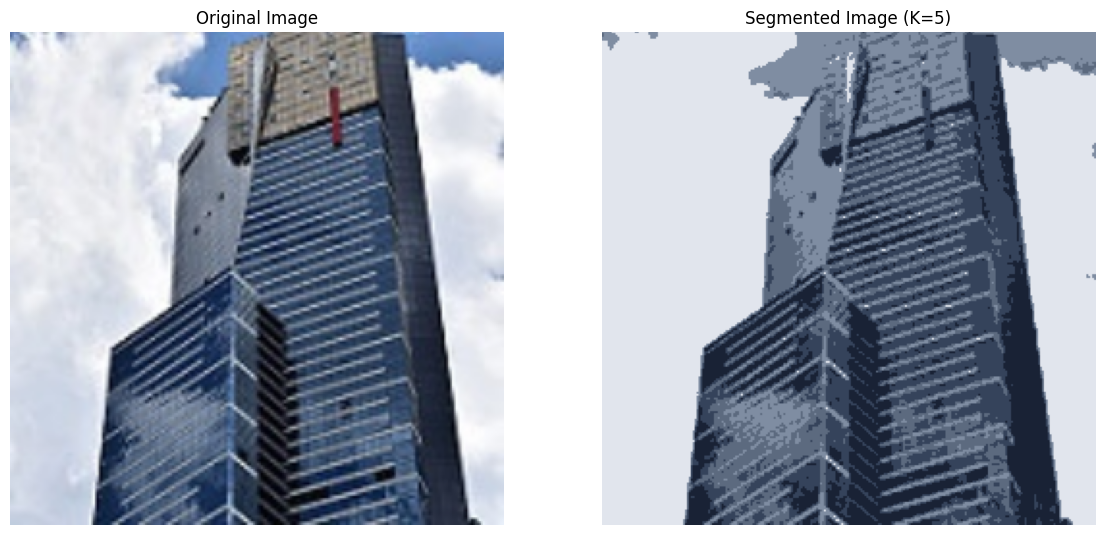

In [36]:
plt.figure(figsize=(14,7))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(segmented_image)
plt.title("Segmented Image (K=5)")
plt.axis("off")

plt.show()

## 11.Compare Different Values of K

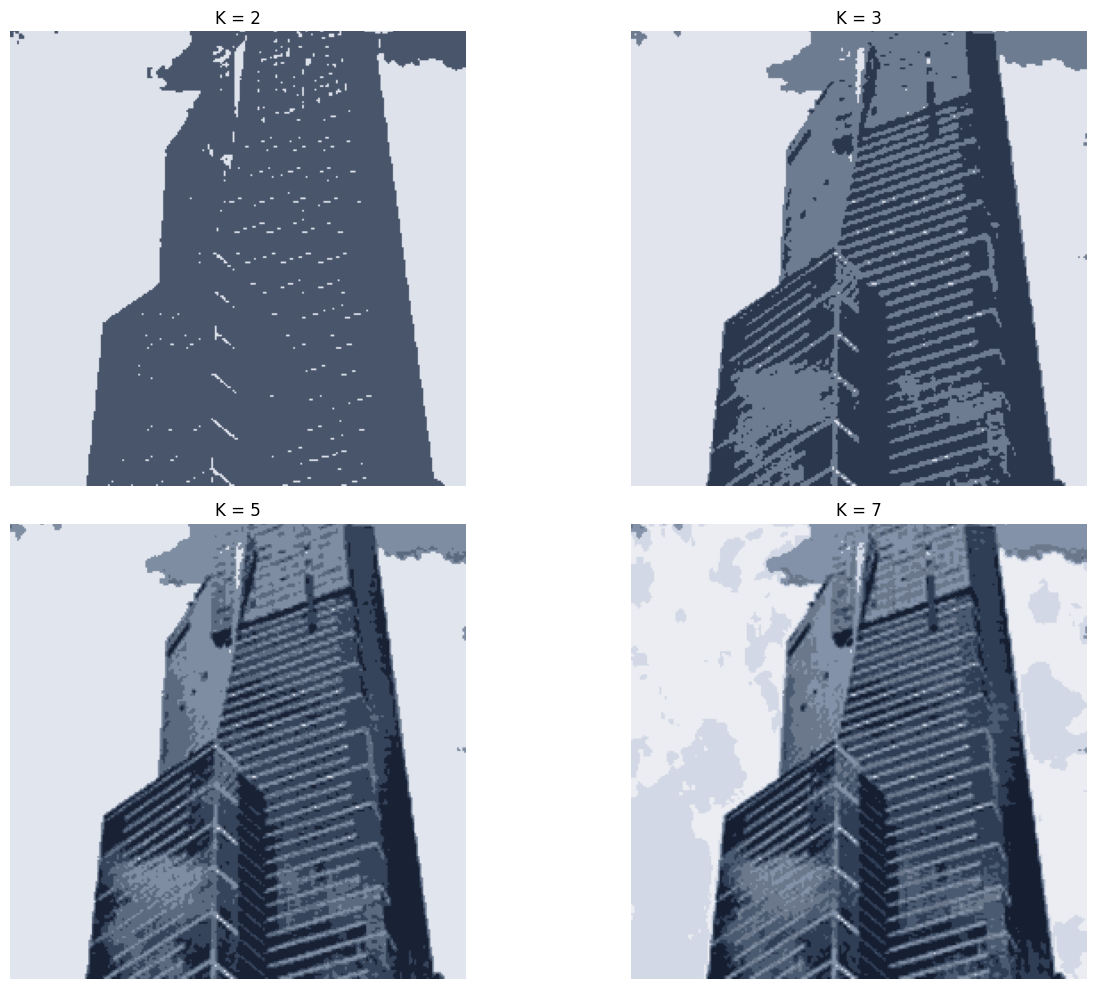

In [37]:
Ks = [2,3,5,7]

plt.figure(figsize=(14,10))

for i,k in enumerate(Ks):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(pixel_values)

    centers = np.uint8(kmeans.cluster_centers_)

    segmented = centers[labels]

    segmented = segmented.reshape(image.shape)

    plt.subplot(2,2,i+1)

    plt.imshow(segmented)

    plt.title(f"K = {k}")

    plt.axis("off")

plt.tight_layout()

plt.show()

## 12.Display Image Information

In [38]:
print("="*50)
print("IMAGE SEGMENTATION USING K-MEANS")
print("="*50)

print(f"Selected Image : {image_name}")
print(f"Image Size     : {image.shape}")
print(f"Number of Pixels: {pixel_values.shape[0]}")
print(f"Features       : {pixel_values.shape[1]}")
print(f"Number of Clusters (K): 5")

IMAGE SEGMENTATION USING K-MEANS
Selected Image : 20057.jpg
Image Size     : (256, 256, 3)
Number of Pixels: 65536
Features       : 3
Number of Clusters (K): 5


## 13.Save the Segmented Image

In [39]:
output = cv2.cvtColor(segmented_image, cv2.COLOR_RGB2BGR)

cv2.imwrite("segmented_image.jpg", output)

print("Segmented image saved as segmented_image.jpg")

Segmented image saved as segmented_image.jpg


## 14.Conclusion

In [40]:
print("""
Conclusion

1. The image was successfully segmented using the K-Means algorithm.

2. Every pixel was assigned to the nearest cluster centroid.

3. Pixels with similar colors were grouped into the same cluster.

4. The segmented image contains only five dominant colors.

5. K-Means reduced image complexity while preserving the major visual structures.
""")


Conclusion

1. The image was successfully segmented using the K-Means algorithm.

2. Every pixel was assigned to the nearest cluster centroid.

3. Pixels with similar colors were grouped into the same cluster.

4. The segmented image contains only five dominant colors.

5. K-Means reduced image complexity while preserving the major visual structures.

